In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
import joblib

In [2]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = str(df[col].dtype)
        
        if col_type == 'object' or col_type == 'category':
            df[col] = df[col].astype('category')
            continue 

        try:
            c_min = df[col].min()
            c_max = df[col].max()
        except:
            df[col] = df[col].astype('category')
            continue

        if 'int' in col_type:
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                df[col] = df[col].astype(np.int64)  
        elif 'float' in col_type:
            if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                df[col] = df[col].astype(np.float16)
            elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df

In [3]:
df_id = pd.read_csv("/home/mostafashazly/Desktop/ieee-fraud-detection/ieee-fraud-detection/train_identity.csv")
df_id.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [4]:
df_tran = pd.read_csv("/home/mostafashazly/Desktop/ieee-fraud-detection/ieee-fraud-detection/train_transaction.csv")
df_tran.head()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df_trainid = reduce_mem_usage(df_id)
df_trans = reduce_mem_usage(df_tran)

Memory usage of dataframe is 56.51 MB
Memory usage after optimization is: 9.95 MB
Decreased by 82.4%
Memory usage of dataframe is 1791.67 MB
Memory usage after optimization is: 487.16 MB
Decreased by 72.8%


In [6]:
list_tittle = df_trainid[['TransactionID','DeviceType','DeviceInfo']] 
final_data_for_train = pd.merge(df_trans,list_tittle,on="TransactionID",how="left" ) 

In [7]:
final_data_for_train['TransactionAmt'] = final_data_for_train['TransactionAmt'].astype('float32')
final_data_for_train['TransactionAmt'].nlargest(10)

274336    31936.0
274339    31936.0
296021     6452.0
248413     6084.0
384603     5544.0
275529     5420.0
275535     5420.0
584767     5368.0
171451     5280.0
303106     5280.0
Name: TransactionAmt, dtype: float32

In [8]:
final_data_for_train.head(10)

/home/mostafashazly/miniconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V332,V333,V334,V335,V336,V337,V338,V339,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
fraud_data = final_data_for_train[final_data_for_train['isFraud'] == 1]
fraud_data.info()
print('\nvalues',fraud_data['TransactionAmt'].mean(),'\n')
fraud_data["TransactionAmt"].value_counts(normalize=True)

<class 'pandas.DataFrame'>
Index: 20663 entries, 203 to 590526
Columns: 396 entries, TransactionID to DeviceInfo
dtypes: category(16), float16(331), float32(45), int16(1), int32(2), int8(1)
memory usage: 17.3 MB

values 149.24435 



TransactionAmt
117.000000     0.034796
59.000000      0.031264
150.000000     0.027392
100.000000     0.025456
49.000000      0.022698
                 ...   
1220.000000    0.000048
4.628906       0.000048
148.000000     0.000048
24.656250      0.000048
2.890625       0.000048
Name: proportion, Length: 2126, dtype: float64

In [10]:

number_of_duplicats = fraud_data.duplicated().sum()
number_of_missing_values = fraud_data.isna().sum()
print(f"number_of_duplicats is: {number_of_duplicats}\n")
print(f"number_of_missing_values is: {number_of_missing_values}")

number_of_duplicats is: 0

number_of_missing_values is: TransactionID         0
isFraud               0
TransactionDT         0
TransactionAmt        0
ProductCD             0
                  ...  
V337              16977
V338              16977
V339              16977
DeviceType         9452
DeviceInfo        12056
Length: 396, dtype: int64


In [11]:
drop_col = fraud_data.columns[(fraud_data.isna().mean() >=0.8)].to_list()

In [12]:
data_droped = fraud_data.drop(columns=drop_col)
data_droped.head(10)

/home/mostafashazly/miniconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V314,V315,V316,V317,V318,V319,V320,V321,DeviceType,DeviceInfo
203,2987203,1,89760,445.000000,W,18268,583.0,150.0,visa,226.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
240,2987240,1,90193,37.093750,C,13413,103.0,185.0,visa,137.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,Redmi Note 4 Build/MMB29M
243,2987243,1,90246,37.093750,C,13413,103.0,185.0,visa,137.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,Redmi Note 4 Build/MMB29M
245,2987245,1,90295,37.093750,C,13413,103.0,185.0,visa,137.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,Redmi Note 4 Build/MMB29M
288,2987288,1,90986,155.500000,C,16578,545.0,185.0,visa,226.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,NaN
367,2987367,1,92350,225.000000,R,4425,562.0,150.0,mastercard,197.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,desktop,rv:52.0
405,2987405,1,92999,90.562500,C,4504,500.0,185.0,mastercard,219.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,NaN
630,2987630,1,97843,12.328125,C,5812,408.0,185.0,mastercard,224.0,...,12.328125,12.328125,0.0,0.0,0.0,0.0,0.0,0.0,desktop,Windows
683,2987683,1,99584,124.375000,C,5812,408.0,185.0,mastercard,224.0,...,24.656250,24.656250,0.0,0.0,0.0,0.0,0.0,0.0,desktop,Windows
736,2987736,1,100591,100.000000,W,15063,NaN,150.0,visa,226.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [13]:
print(data_droped['DeviceType'].isna().sum())
print(data_droped['DeviceInfo'].isna().sum())


9452
12056


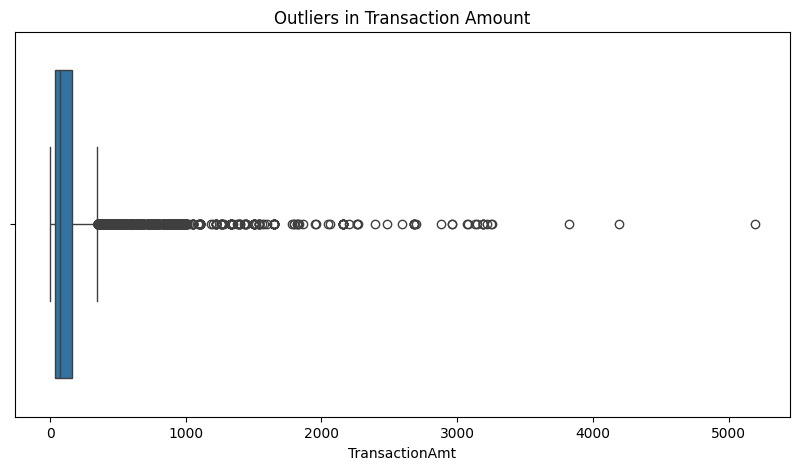

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data_droped, x='TransactionAmt')
plt.title('Outliers in Transaction Amount')
plt.show()

Text(0.5, 1.0, 'Transaction Amount (Log Scale)')

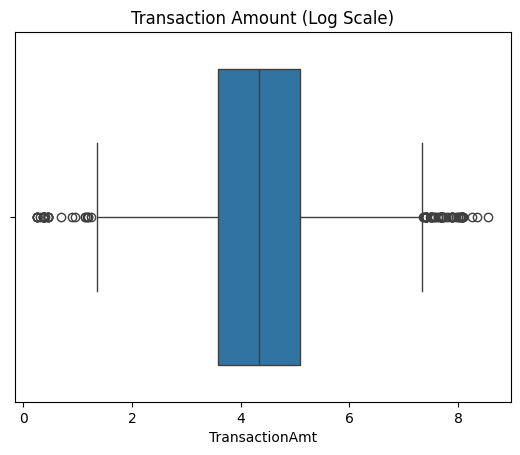

In [15]:
sns.boxplot(data=data_droped, x=np.log1p(data_droped['TransactionAmt']))
plt.title('Transaction Amount (Log Scale)')

In [16]:
data_droped['TransactionAmt'].nlargest(15)

422708    5192.0
252544    4192.0
468844    3822.0
449956    3260.0
226827    3248.0
296902    3220.0
369285    3192.0
230736    3190.0
369349    3190.0
434871    3190.0
203082    3148.0
563264    3134.0
26694     3082.0
504411    3076.0
431094    2964.0
Name: TransactionAmt, dtype: float32

/tmp/ipykernel_9564/1268425771.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_droped['TransactionAmt_Log'] = np.log1p(data_droped['TransactionAmt'])


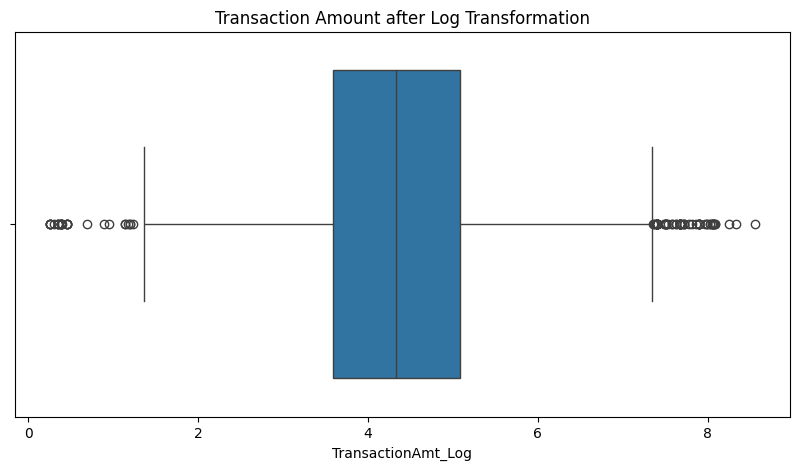

In [17]:
data_droped['TransactionAmt_Log'] = np.log1p(data_droped['TransactionAmt'])

plt.figure(figsize=(10, 5))
sns.boxplot(data=data_droped, x='TransactionAmt_Log')
plt.title('Transaction Amount after Log Transformation')
plt.show()

In [18]:
data_droped['TransactionAmt_Log'].nlargest()

422708    8.555067
252544    8.341172
468844    8.248791
449956    8.089789
226827    8.086102
Name: TransactionAmt_Log, dtype: float32

In [19]:
data_os = data_droped[(data_droped['DeviceInfo'].isna()) & (data_droped['DeviceType'].isna())]
print(data_os['TransactionAmt_Log'].nlargest())

422708    8.555067
252544    8.341172
468844    8.248791
449956    8.089789
226827    8.086102
Name: TransactionAmt_Log, dtype: float32


In [20]:
data_os = data_droped[(data_droped['DeviceInfo'].notna()) & (data_droped['DeviceType'].notna())]
print(data_os['TransactionAmt_Log'].nlargest())

533442    7.496098
227775    7.313887
265557    7.313887
414035    7.313887
414104    7.313887
Name: TransactionAmt_Log, dtype: float32


In [21]:
data_droped['DeviceInfo'] = data_droped['DeviceInfo'].cat.add_categories('Unknown')
data_droped['DeviceType'] = data_droped['DeviceType'].cat.add_categories('Unknown')


data_droped['DeviceInfo'] = data_droped['DeviceInfo'].fillna('Unknown')
data_droped['DeviceType'] = data_droped['DeviceType'].fillna('Unknown')

print(data_droped.groupby('DeviceType')['TransactionAmt'].mean())

DeviceType
desktop     80.999855
mobile      96.592117
Unknown    220.857086
Name: TransactionAmt, dtype: float32


In [22]:
data_droped.head(10)

/home/mostafashazly/miniconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V315,V316,V317,V318,V319,V320,V321,DeviceType,DeviceInfo,TransactionAmt_Log
203,2987203,1,89760,445.000000,W,18268,583.0,150.0,visa,226.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,Unknown,Unknown,6.100319
240,2987240,1,90193,37.093750,C,13413,103.0,185.0,visa,137.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,Redmi Note 4 Build/MMB29M,3.640050
243,2987243,1,90246,37.093750,C,13413,103.0,185.0,visa,137.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,Redmi Note 4 Build/MMB29M,3.640050
245,2987245,1,90295,37.093750,C,13413,103.0,185.0,visa,137.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,Redmi Note 4 Build/MMB29M,3.640050
288,2987288,1,90986,155.500000,C,16578,545.0,185.0,visa,226.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,Unknown,5.053056
367,2987367,1,92350,225.000000,R,4425,562.0,150.0,mastercard,197.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,desktop,rv:52.0,5.420535
405,2987405,1,92999,90.562500,C,4504,500.0,185.0,mastercard,219.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,Unknown,4.517022
630,2987630,1,97843,12.328125,C,5812,408.0,185.0,mastercard,224.0,...,12.328125,0.0,0.0,0.0,0.0,0.0,0.0,desktop,Windows,2.589876
683,2987683,1,99584,124.375000,C,5812,408.0,185.0,mastercard,224.0,...,24.656250,0.0,0.0,0.0,0.0,0.0,0.0,desktop,Windows,4.831309
736,2987736,1,100591,100.000000,W,15063,NaN,150.0,visa,226.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,Unknown,Unknown,4.615120


In [23]:
cat_cols = data_droped.select_dtypes(include=['category']).columns.tolist()
print(cat_cols)

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType', 'DeviceInfo']


In [24]:
print(data_droped['card1'].isna().sum())
print(data_droped['card2'].isna().sum())
print(data_droped['card3'].isna().sum())
data_droped['card2']=data_droped['card2'].astype('Float32')

print('\n',data_droped.groupby('card1')['TransactionAmt'].nlargest())


0
423
39

 card1        
1015   468404    450.0000
1016   294990    100.0000
1022   178194    300.0000
1030   564074    125.0000
1039   472939     77.9375
                   ...   
18375  276403    365.0000
       423272    350.5000
       194457    335.0000
       233556    300.0000
       236123    300.0000
Name: TransactionAmt, Length: 4757, dtype: float32


In [25]:
print(data_droped.groupby('card2')['TransactionAmt'].nlargest())


card2        
100.0  422990    554.0000
       257199    450.0000
       307230    450.0000
       307231    450.0000
       318653    450.0000
                   ...   
599.0  576858     75.0000
       277006     65.0000
600.0  572340     59.0000
       553737     49.0000
       581181     47.9375
Name: TransactionAmt, Length: 1187, dtype: float32


In [26]:
data_droped['card3'] = data_droped['card3'].astype('Float32')
print(data_droped.groupby('card3')['TransactionAmt'].nlargest())

card3        
100.0  556051    132.7500
       556057    132.7500
       431609     86.3125
       379991     85.0625
       380008     85.0625
                   ...   
223.0  297661    300.0000
       234774    200.0000
224.0  376847     27.1875
229.0  193129    664.0000
231.0  568160    150.0000
Name: TransactionAmt, Length: 181, dtype: float32


In [27]:
card_info = data_droped[data_droped['card1'] == 18375]

print(card_info[['TransactionAmt','DeviceType', 'DeviceInfo', 'card1', 'card2', 'card3', 'card4']].head())

        TransactionAmt DeviceType DeviceInfo  card1  card2  card3 card4
194457           335.0    Unknown    Unknown  18375  523.0  150.0  visa
206617            30.0    desktop    Windows  18375  174.0  150.0  visa
218662            25.0    desktop    Windows  18375  174.0  150.0  visa
226111            30.0    desktop    Windows  18375  174.0  150.0  visa
226121            30.0    desktop    Windows  18375  174.0  150.0  visa


In [28]:
card_info = data_droped[data_droped['card2'] == 100.0]

print(card_info[['TransactionAmt','DeviceType', 'DeviceInfo', 'card1', 'card2', 'card3', 'card4']].head())

       TransactionAmt DeviceType DeviceInfo  card1  card2  card3 card4
1643            110.0    Unknown    Unknown   2803  100.0  150.0  visa
7462            265.0    Unknown    Unknown  11106  100.0  150.0  visa
13601            75.0    Unknown    Unknown   2803  100.0  150.0  visa
13633            83.5    Unknown    Unknown   2803  100.0  150.0  visa
15957           226.0    Unknown    Unknown   2803  100.0  150.0  visa


In [29]:
card_info = data_droped[data_droped['card3'] == 100.0]

print(card_info[['TransactionAmt','DeviceType', 'DeviceInfo', 'card1', 'card2', 'card3', 'card4']].head())

        TransactionAmt DeviceType DeviceInfo  card1  card2  card3       card4
226915        8.460938    desktop    Unknown  13822  555.0  100.0  mastercard
379991       85.062500    desktop    Windows  17392  555.0  100.0  mastercard
380008       85.062500    desktop    Windows  17392  555.0  100.0  mastercard
380046       85.062500    desktop    Windows  17392  555.0  100.0  mastercard
390249       54.937500    desktop    Unknown  17532  555.0  100.0  mastercard


In [30]:
data_droped.head(10)

/home/mostafashazly/miniconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/mostafashazly/miniconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V315,V316,V317,V318,V319,V320,V321,DeviceType,DeviceInfo,TransactionAmt_Log
203,2987203,1,89760,445.000000,W,18268,583.0,150.0,visa,226.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,Unknown,Unknown,6.100319
240,2987240,1,90193,37.093750,C,13413,103.0,185.0,visa,137.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,Redmi Note 4 Build/MMB29M,3.640050
243,2987243,1,90246,37.093750,C,13413,103.0,185.0,visa,137.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,Redmi Note 4 Build/MMB29M,3.640050
245,2987245,1,90295,37.093750,C,13413,103.0,185.0,visa,137.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,Redmi Note 4 Build/MMB29M,3.640050
288,2987288,1,90986,155.500000,C,16578,545.0,185.0,visa,226.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,Unknown,5.053056
367,2987367,1,92350,225.000000,R,4425,562.0,150.0,mastercard,197.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,desktop,rv:52.0,5.420535
405,2987405,1,92999,90.562500,C,4504,500.0,185.0,mastercard,219.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,mobile,Unknown,4.517022
630,2987630,1,97843,12.328125,C,5812,408.0,185.0,mastercard,224.0,...,12.328125,0.0,0.0,0.0,0.0,0.0,0.0,desktop,Windows,2.589876
683,2987683,1,99584,124.375000,C,5812,408.0,185.0,mastercard,224.0,...,24.656250,0.0,0.0,0.0,0.0,0.0,0.0,desktop,Windows,4.831309
736,2987736,1,100591,100.000000,W,15063,<NA>,150.0,visa,226.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,Unknown,Unknown,4.615120


In [31]:
categorical_cols = data_droped.select_dtypes(include=['object', 'category']).columns.tolist()

numerical_cols = data_droped.select_dtypes(include=['number']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("\nNumerical Columns:", numerical_cols)

Categorical Columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType', 'DeviceInfo']

Numerical Columns: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73

In [32]:
for col in categorical_cols:
    if data_droped[col].dtype.name == 'category':
        if 'Unknown' not in data_droped[col].cat.categories:
            data_droped[col] = data_droped[col].cat.add_categories('Unknown')
    
    data_droped[col] = data_droped[col].fillna('Unknown')

data_droped[numerical_cols] = data_droped[numerical_cols].fillna(-1)

In [33]:
print("Total Missing Values:", data_droped.isna().sum().sum())

Total Missing Values: 0


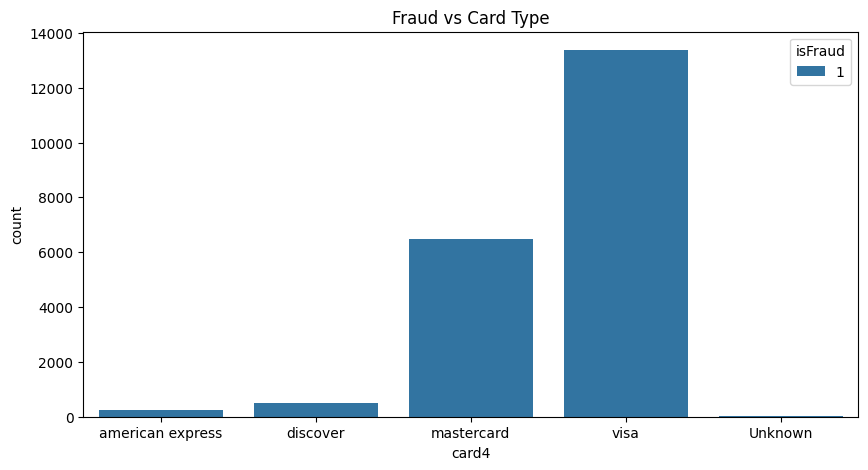

In [34]:
plt.figure(figsize=(10,5))
sns.countplot(data=data_droped, x='card4', hue='isFraud')
plt.title('Fraud vs Card Type')
plt.show()

/tmp/ipykernel_9564/4021991613.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=data_droped[data_droped['isFraud']==0]['TransactionAmt_Log'], label='Normal', shade=True)
/tmp/ipykernel_9564/4021991613.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=data_droped[data_droped['isFraud']==1]['TransactionAmt_Log'], label='Fraud', shade=True)


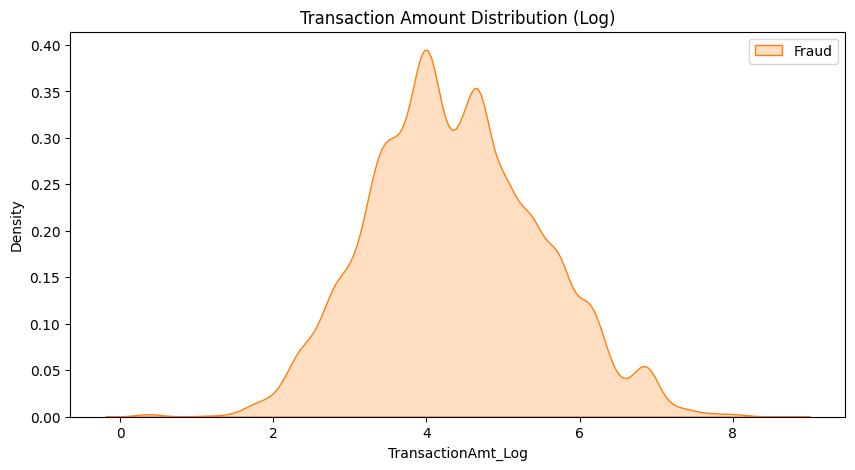

In [35]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=data_droped[data_droped['isFraud']==0]['TransactionAmt_Log'], label='Normal', shade=True)
sns.kdeplot(data=data_droped[data_droped['isFraud']==1]['TransactionAmt_Log'], label='Fraud', shade=True)
plt.title('Transaction Amount Distribution (Log)')
plt.legend()
plt.show()

In [36]:
drop_col_all = final_data_for_train.columns[(final_data_for_train.isna().mean() >= 0.8)].to_list()
df_clean = final_data_for_train.drop(columns=drop_col_all)

In [37]:
df_clean['TransactionAmt_Log'] = np.log1p(df_clean['TransactionAmt'])

/tmp/ipykernel_9564/2481387589.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['TransactionAmt_Log'] = np.log1p(df_clean['TransactionAmt'])


In [38]:
cat_cols_all = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_all = df_clean.select_dtypes(include=['number', 'float16', 'float32', 'int8', 'int16']).columns.tolist()

In [39]:
for col in cat_cols_all:
    if 'Unknown' not in df_clean[col].cat.categories:
        df_clean[col] = df_clean[col].cat.add_categories('Unknown')
    df_clean[col] = df_clean[col].fillna('Unknown')
df_clean[num_cols_all] = df_clean[num_cols_all].fillna(-1)
print("Total Missing in Full Data:", df_clean.isna().sum().sum())

Total Missing in Full Data: 0


/tmp/ipykernel_9564/217478267.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df_clean[df_clean['isFraud']==0]['TransactionAmt_Log'], label='Normal (0)', shade=True)
/tmp/ipykernel_9564/217478267.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df_clean[df_clean['isFraud']==1]['TransactionAmt_Log'], label='Fraud (1)', shade=True)


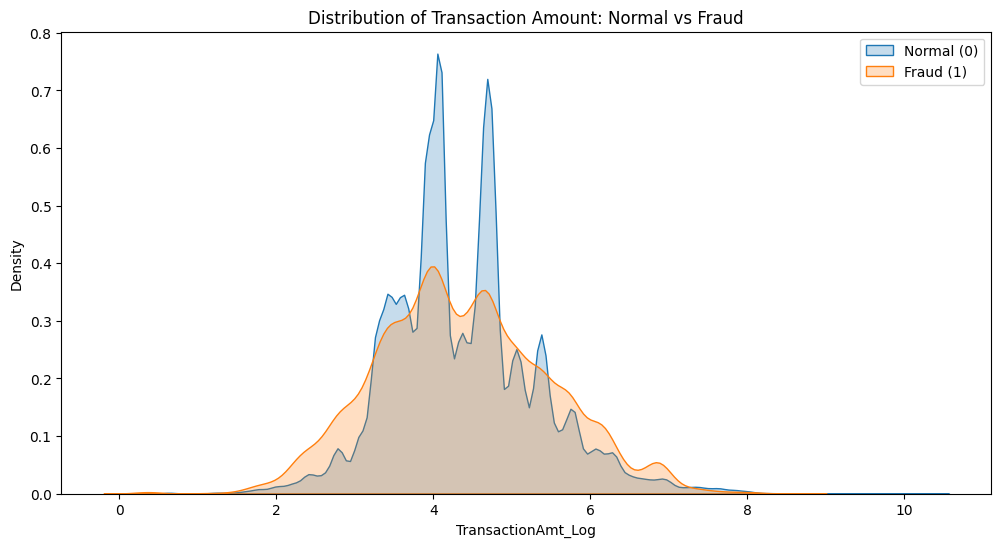

In [40]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_clean[df_clean['isFraud']==0]['TransactionAmt_Log'], label='Normal (0)', shade=True)
sns.kdeplot(data=df_clean[df_clean['isFraud']==1]['TransactionAmt_Log'], label='Fraud (1)', shade=True)
plt.title('Distribution of Transaction Amount: Normal vs Fraud')
plt.legend()
plt.show()

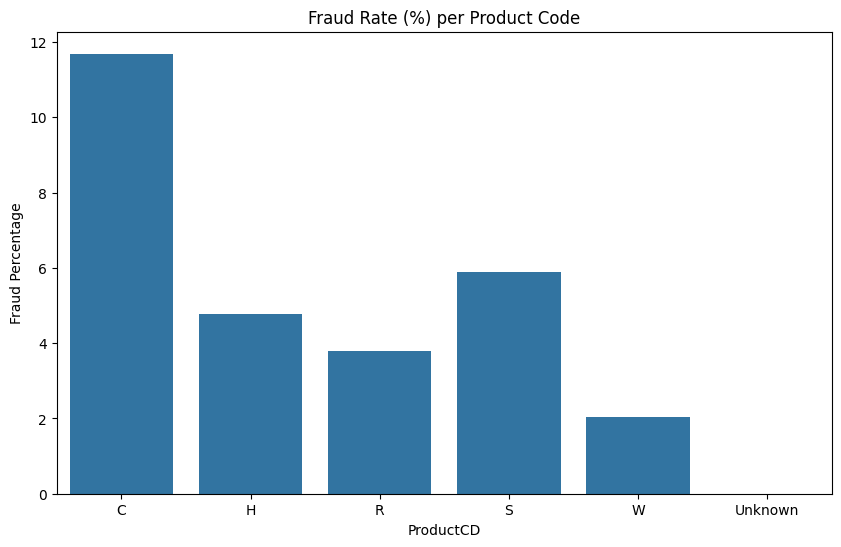

ProductCD
C    11.687269
S     5.899553
H     4.766231
R     3.782594
W     2.039939
Name: isFraud, dtype: float64


In [41]:
product_fraud = df_clean.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10,6))
sns.barplot(x=product_fraud.index, y=product_fraud.values)
plt.title('Fraud Rate (%) per Product Code')
plt.ylabel('Fraud Percentage')
plt.show()

print(product_fraud)

In [42]:
df_clean['Hour'] = (df_clean['TransactionDT'] / (3600)) % 24
df_clean['Hour'].head(10)

/tmp/ipykernel_9564/2163021260.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['Hour'] = (df_clean['TransactionDT'] / (3600)) % 24


0    0.000000
1    0.000278
2    0.019167
3    0.027500
4    0.029444
5    0.030556
6    0.033889
7    0.035833
8    0.037500
9    0.037778
Name: Hour, dtype: float64

/tmp/ipykernel_9564/2095529546.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df_clean[df_clean['isFraud']==0]['Hour'], label='Normal', shade=True)
/tmp/ipykernel_9564/2095529546.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df_clean[df_clean['isFraud']==1]['Hour'], label='Fraud', shade=True)


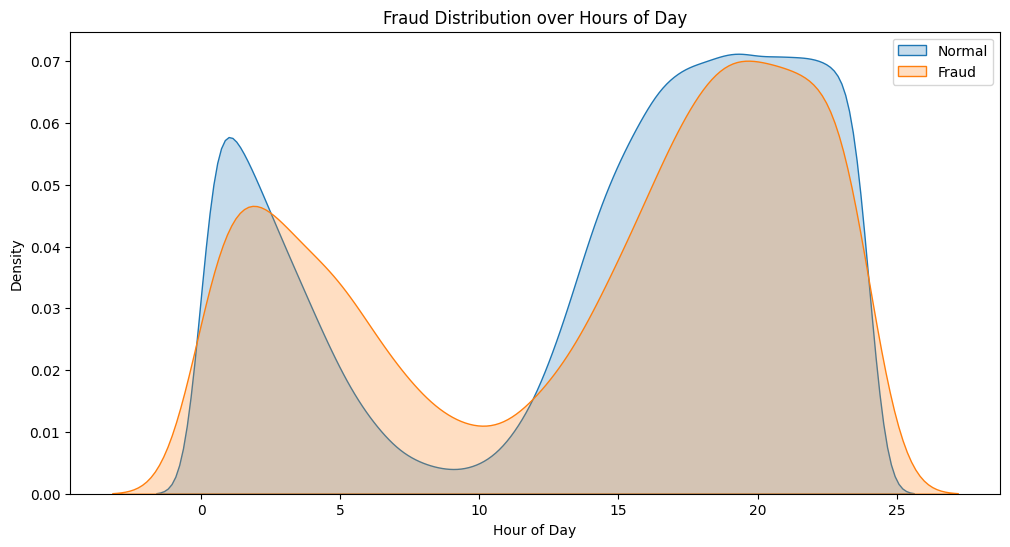

In [43]:
plt.figure(figsize=(12,6))
sns.kdeplot(data=df_clean[df_clean['isFraud']==0]['Hour'], label='Normal', shade=True)
sns.kdeplot(data=df_clean[df_clean['isFraud']==1]['Hour'], label='Fraud', shade=True)
plt.title('Fraud Distribution over Hours of Day')
plt.xlabel('Hour of Day')
plt.legend()
plt.show()

In [44]:
df_clean['Hour_int'] = df_clean['Hour'].astype(int)
pivot = df_clean.pivot_table(values='isFraud', index='card4', columns='Hour_int', aggfunc='mean')

/tmp/ipykernel_9564/4216436808.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['Hour_int'] = df_clean['Hour'].astype(int)


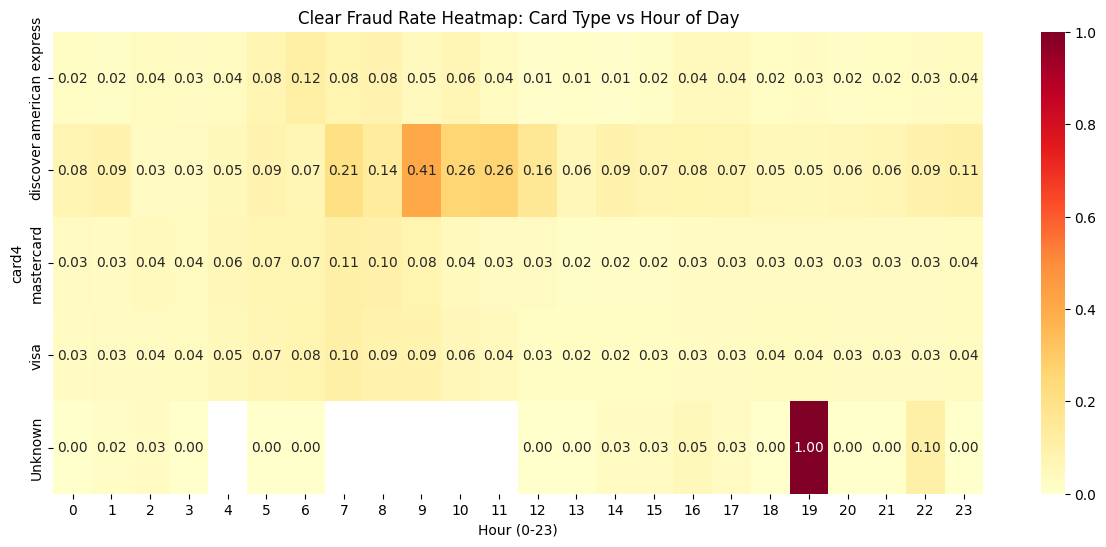

In [45]:

plt.figure(figsize=(15, 6))
sns.heatmap(pivot,annot=True,cmap='YlOrRd',fmt='.2f') 
plt.title('Clear Fraud Rate Heatmap: Card Type vs Hour of Day')
plt.xlabel('Hour (0-23)')
plt.show()

In [46]:
df_clean.head()

/home/mostafashazly/miniconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V317,V318,V319,V320,V321,DeviceType,DeviceInfo,TransactionAmt_Log,Hour,Hour_int
0,2987000,0,86400,68.5,W,13926,-1.0,150.0,discover,142.0,...,117.0,0.0,0.0,0.0,0.0,Unknown,Unknown,4.241327,0.000000,0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,Unknown,Unknown,3.401197,0.000278,0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,0.0,0.0,0.0,0.0,0.0,Unknown,Unknown,4.094345,0.019167,0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,1404.0,790.0,0.0,0.0,0.0,Unknown,Unknown,3.931826,0.027500,0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,mobile,SAMSUNG SM-G892A Build/NRD90M,3.931826,0.029444,0


In [47]:
df_clean['DeviceInfo'] = df_clean['DeviceInfo'].str.lower()

In [48]:
df_clean['device_combined'] = df_clean['DeviceType'].astype(str) + "_" + df_clean['DeviceInfo'].astype(str)
print(df_clean['device_combined'].value_counts().head(10))

device_combined
Unknown_unknown                 449685
desktop_windows                  47720
mobile_ios device                19781
desktop_macos                    12565
desktop_unknown                  11715
mobile_unknown                   10474
desktop_trident/7.0               7407
desktop_rv:11.0                   1864
desktop_rv:57.0                    871
mobile_sm-j700m build/mmb29k       549
Name: count, dtype: int64


/tmp/ipykernel_9564/3935066362.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['device_combined'] = df_clean['DeviceType'].astype(str) + "_" + df_clean['DeviceInfo'].astype(str)


In [49]:
df_clean = df_clean.copy()

In [50]:
print(df_clean['addr2'].value_counts().head(5))

addr2
 87.0    520481
-1.0      65706
 60.0      3084
 96.0       638
 32.0        91
Name: count, dtype: int64


In [51]:
addr1_counts = df_clean['addr1'].value_counts()
df_clean['addr1_freq'] = df_clean['addr1'].astype('Float32').map(addr1_counts)
print(df_clean[['addr1', 'addr1_freq']].head())

addr1_counts = df_clean['addr1'].value_counts()
joblib.dump(addr1_counts, 'addr1_counts.pkl')

   addr1  addr1_freq
0  315.0       23078
1  325.0       42751
2  330.0       26287
3  476.0        9478
4  420.0        3581


/home/mostafashazly/miniconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


['addr1_counts.pkl']

In [53]:
print(df_clean['P_emaildomain'].value_counts().head(10))

P_emaildomain
gmail.com        228355
yahoo.com        100934
Unknown           94456
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
Name: count, dtype: int64


In [54]:
df_clean['email_check'] = (df_clean['P_emaildomain'].astype('str') == df_clean['R_emaildomain']).astype(int)

print(df_clean['email_check'].value_counts())

email_check
0    404644
1    185896
Name: count, dtype: int64


In [55]:
print(df_clean.groupby('email_check')['isFraud'].mean())

email_check
0    0.021337
1    0.064708
Name: isFraud, dtype: float64


In [56]:
df_clean['dist1_is_unknown'] = (df_clean['dist1'] == -1).astype(int)
df_clean['dist1_log'] = np.log1p(df_clean['dist1'].replace(-1, 0))
print(df_clean.groupby('dist1_is_unknown')['isFraud'].mean())

dist1_is_unknown
0    0.019956
1    0.045158
Name: isFraud, dtype: float64


In [57]:
scaler_d = MinMaxScaler()

d_nums = [1, 2, 3, 4, 5, 10, 11, 15]
d_original_cols = [f'D{i}' for i in d_nums]
d_log_cols = [f'D{i}_log' for i in d_nums]

df_clean['D1_is_unknown'] = (df_clean['D1'] == -1).astype(int)

for col in d_original_cols:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col].clip(lower=0))

df_clean[d_log_cols] = scaler_d.fit_transform(df_clean[d_log_cols])

if 'D1' in df_clean.columns and 'D2' in df_clean.columns:
    df_clean['D1_minus_D2'] = df_clean['D1'] - df_clean['D2']

print("Done! D columns processed correctly.")
joblib.dump(scaler_d, 'scaler_d.pkl')

Done! D columns processed correctly.


['scaler_d.pkl']

In [ ]:
print("Max values for D logs:")
print(df_clean[d_log_cols].max())

print("\nMin values for D logs:")
print(df_clean[d_log_cols].min())

if 'D1_minus_D2' in df_clean.columns:
    print("\nSample of D1_minus_D2 (First 5):")
    print(df_clean['D1_minus_D2'].head())

Max values for D logs:
D1_log     1.0
D2_log     1.0
D3_log     1.0
D4_log     1.0
D5_log     1.0
D10_log    1.0
D11_log    1.0
D15_log    1.0
dtype: float16

Min values for D logs:
D1_log     0.0
D2_log     0.0
D3_log     0.0
D4_log     0.0
D5_log     0.0
D10_log    0.0
D11_log    0.0
D15_log    0.0
dtype: float16

Sample of D1_minus_D2 (First 5):
0    15.0
1     1.0
2     1.0
3     0.0
4     1.0
Name: D1_minus_D2, dtype: float16


/home/mostafashazly/miniconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/mostafashazly/miniconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [58]:
c_cols = [f'C{i}' for i in range(1, 15) if f'C{i}' in df_clean.columns]

for col in c_cols:
    df_clean[f'{col}_is_unknown'] = (df_clean[col] == -1).astype(int)

scaler_c = MinMaxScaler()

for col in c_cols:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col].clip(lower=0))

c_log_cols = [f'{col}_log' for col in c_cols]
df_clean[c_log_cols] = scaler_c.fit_transform(df_clean[c_log_cols])

print("Correlation with Fraud (C1_log):")
print(df_clean[['C1_log', 'isFraud']].corr()['isFraud'])
joblib.dump(scaler_c, 'scaler_c.pkl')

Correlation with Fraud (C1_log):
C1_log     0.08305
isFraud    1.00000
Name: isFraud, dtype: float64


['scaler_c.pkl']

In [ ]:
m_cols = [f'M{i}' for i in range(1, 10) if f'M{i}' in df_clean.columns]

for col in m_cols:
    df_clean[col] = df_clean[col].astype(str).str.lower()
    
    df_clean[col] = df_clean[col].map({'t': 1, 'f': 0, 'true': 1, 'false': 0}).fillna(-1)

print(f"Sample of M columns after encoding:")
print(df_clean[m_cols].head())

Sample of M columns after encoding:
    M1   M2   M3   M4   M5   M6   M7   M8   M9
0  1.0  1.0  1.0 -1.0  0.0  1.0 -1.0 -1.0 -1.0
1 -1.0 -1.0 -1.0 -1.0  1.0  1.0 -1.0 -1.0 -1.0
2  1.0  1.0  1.0 -1.0  0.0  0.0  0.0  0.0  0.0
3 -1.0 -1.0 -1.0 -1.0  1.0  0.0 -1.0 -1.0 -1.0
4 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0


In [59]:
v_cols = [f'V{i}' for i in range(1, 340) if f'V{i}' in df_clean.columns]
scaler_v = MinMaxScaler()
df_clean[v_cols] = scaler_v.fit_transform(df_clean[v_cols].fillna(-1))
joblib.dump(scaler_v, 'scaler_v.pkl')

['scaler_v.pkl']

In [ ]:
df_clean['hour'] = (df_clean['TransactionDT'] // 3600) % 24
df_clean['day_of_week'] = (df_clean['TransactionDT'] // (3600 * 24)) % 7

/tmp/ipykernel_5556/406333078.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['hour'] = (df_clean['TransactionDT'] // 3600) % 24
/tmp/ipykernel_5556/406333078.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['day_of_week'] = (df_clean['TransactionDT'] // (3600 * 24)) % 7


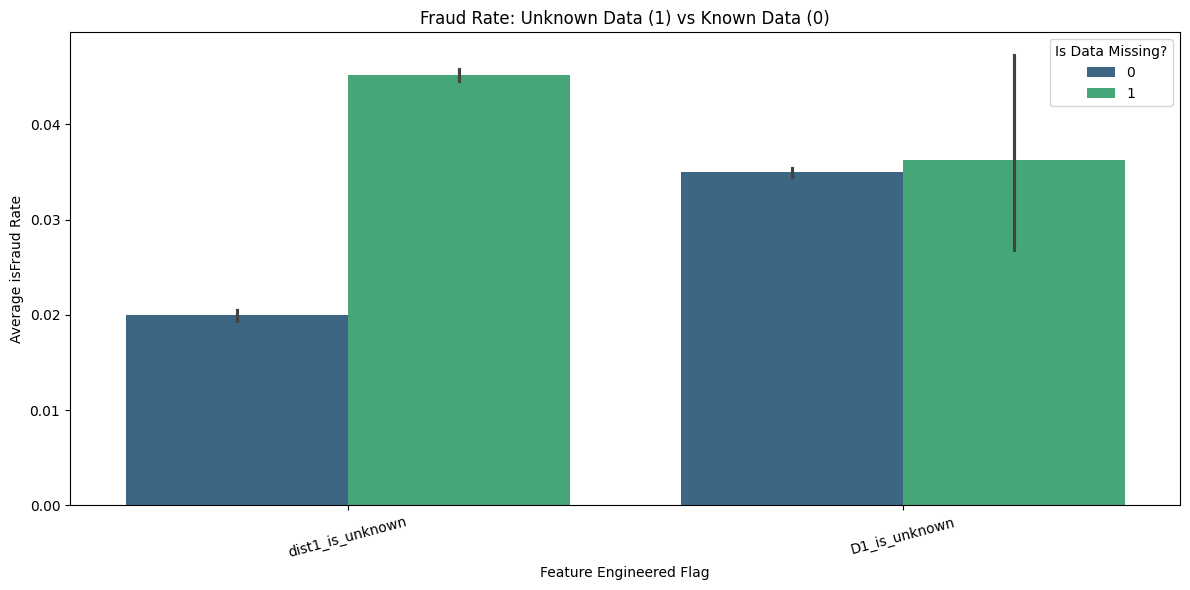

In [ ]:
flags = ['dist1_is_unknown', 'D1_is_unknown']
df_melted = df_clean.melt(id_vars=['isFraud'], value_vars=flags, var_name='Flag_Type', value_name='Is_Mising')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Flag_Type', y='isFraud', hue='Is_Mising', palette='viridis')
plt.title('Fraud Rate: Unknown Data (1) vs Known Data (0)')
plt.ylabel('Average isFraud Rate')
plt.xlabel('Feature Engineered Flag')
plt.xticks(rotation=15)
plt.legend(title='Is Data Missing?')
plt.tight_layout()
plt.show()

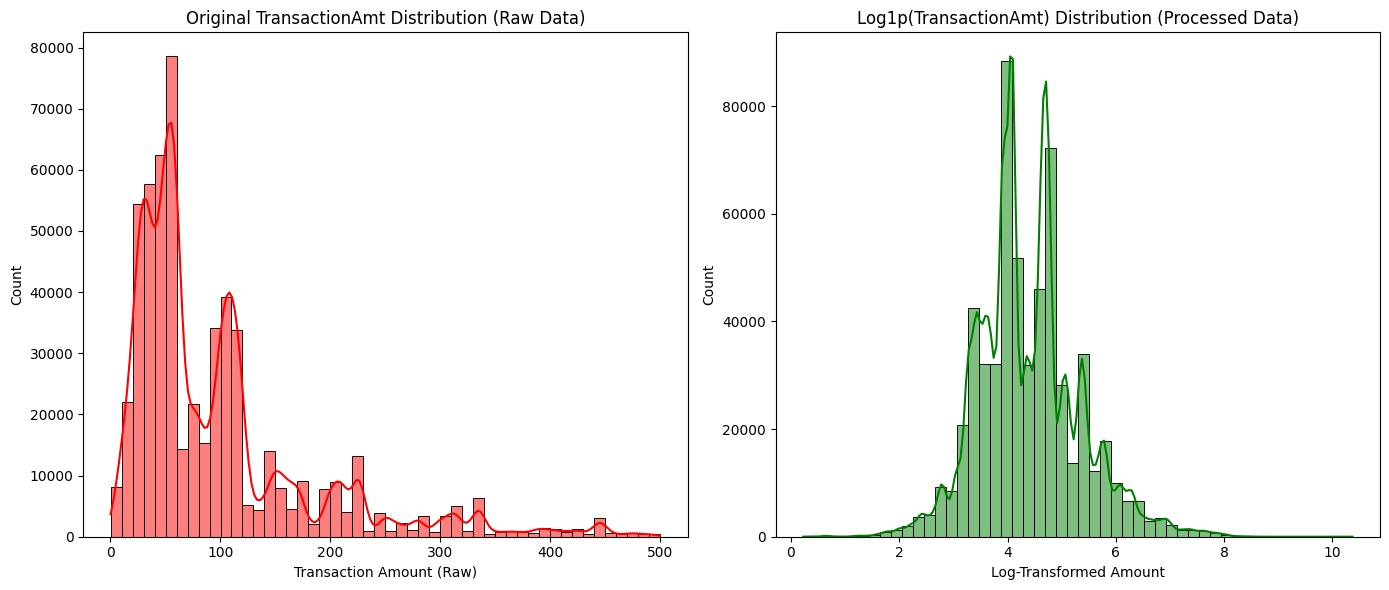

In [ ]:
plt.figure(figsize=(14, 6))

# 1. قبل الـ Log (Skewed Data)
plt.subplot(1, 2, 1)
sns.histplot(df_clean[df_clean['TransactionAmt'] < 500]['TransactionAmt'], bins=50, kde=True, color='red')
plt.title('Original TransactionAmt Distribution (Raw Data)')
plt.xlabel('Transaction Amount (Raw)')

# 2. بعد الـ Log (Normalized Data)
plt.subplot(1, 2, 2)
# هنفترض إننا لسه معملناش الـ log على العمود ده عشان تظهر المقارنة
sns.histplot(np.log1p(df_clean['TransactionAmt']), bins=50, kde=True, color='green')
plt.title('Log1p(TransactionAmt) Distribution (Processed Data)')
plt.xlabel('Log-Transformed Amount')

plt.tight_layout()
plt.show()

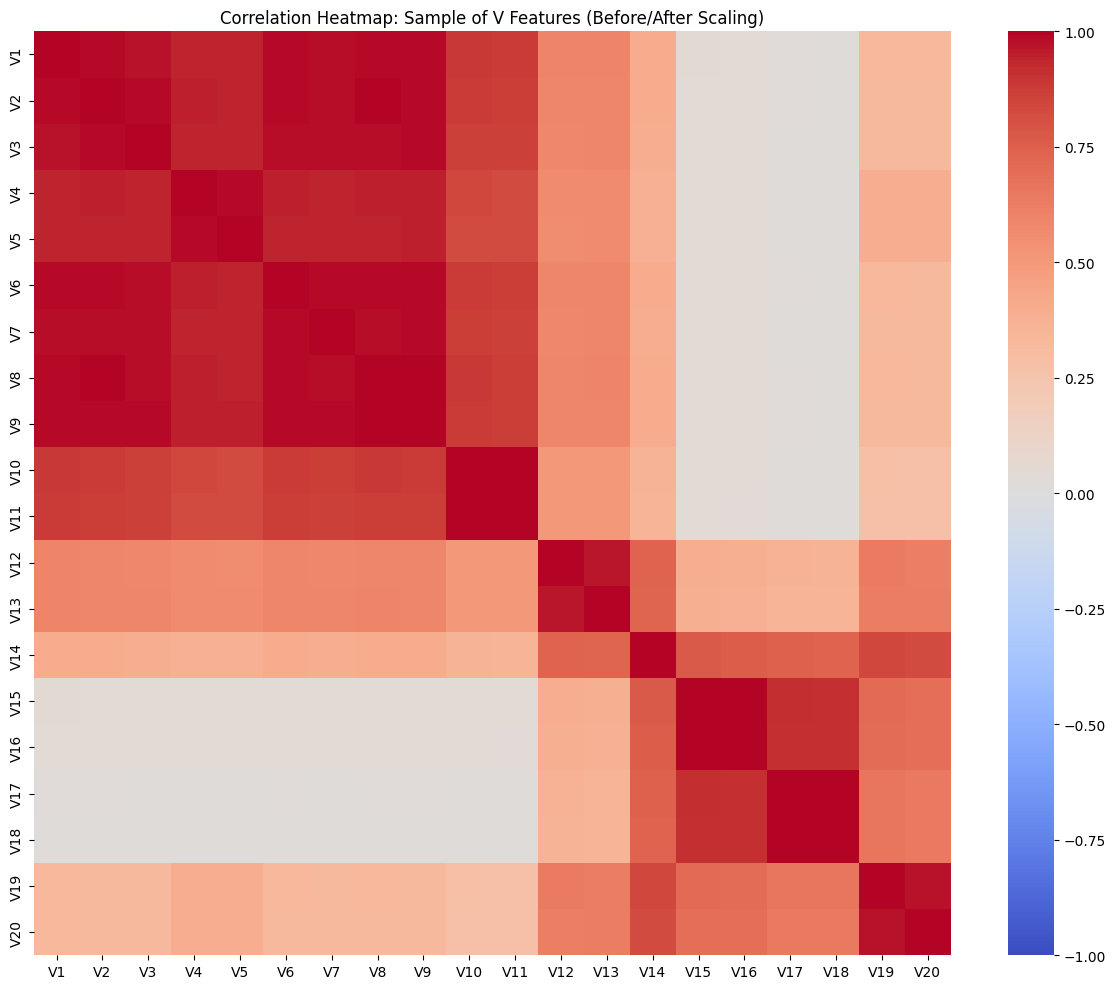

In [ ]:
v_sample_cols = [f'V{i}' for i in range(1, 21) if f'V{i}' in df_clean.columns]
corr_matrix = df_clean[v_sample_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Sample of V Features (Before/After Scaling)')
plt.tight_layout()
plt.show()

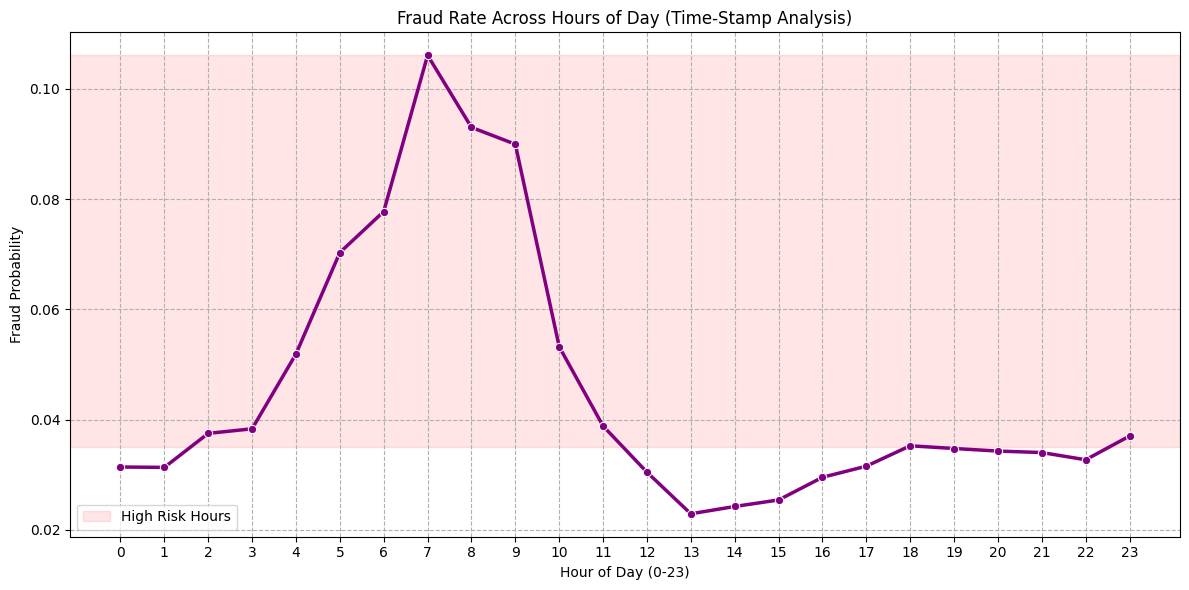

In [ ]:
df_clean['Hour_int'] = df_clean['Hour'].astype(int)

hourly_fraud = df_clean.groupby('Hour_int')['isFraud'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_fraud, x='Hour_int', y='isFraud', marker='o', color='purple', linewidth=2.5)

mean_fraud = df_clean['isFraud'].mean()
plt.axhspan(mean_fraud, hourly_fraud['isFraud'].max(), color='red', alpha=0.1, label='High Risk Hours')

plt.title('Fraud Rate Across Hours of Day (Time-Stamp Analysis)')
plt.ylabel('Fraud Probability')
plt.xlabel('Hour of Day (0-23)')
plt.xticks(range(24))
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
cols_to_drop = [
    'TransactionID', 'TransactionDT', 'TransactionAmt', 
    'dist1', 'Hour', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15']

c_original = [f'C{i}' for i in range(1, 15)]
cols_to_drop.extend(c_original)

df_final = df_clean.drop(columns=cols_to_drop)

print(f"Original columns: {len(df_clean.columns)}")
print(f"Final columns: {len(df_final.columns)}")

Original columns: 389
Final columns: 362


In [ ]:
df_final.columns.to_list()

['isFraud',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'P_emaildomain',
 'R_emaildomain',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V65',
 'V66',
 'V67',
 'V68',
 'V69',
 'V70',
 'V71',
 'V72',
 'V73',
 'V74',
 'V75',
 'V76',
 'V77',
 'V78',
 'V79',
 'V80',
 'V81',
 'V82',
 'V83',
 'V84',
 'V85',
 'V86',
 'V87',
 'V88',
 'V89',
 'V90',
 'V91',
 'V92',
 'V93',
 'V94',
 'V95',
 'V96',
 'V97',
 'V98',
 'V99',
 'V100',
 'V

In [ ]:
dict_encoders = {}
cat_cols = df_final.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    le = LabelEncoder()
    df_final[col] = le.fit_transform(df_final[col].astype(str))
    dict_encoders[col] = le  

joblib.dump(dict_encoders, 'label_encoders_dict.pkl')

X = df_final.drop(columns=['isFraud'])
y = df_final['isFraud']

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

joblib.dump(scaler, 'min_max_scaler.pkl')

df_final_ready = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)
df_final_ready.to_csv('train_final_processed.csv', index=False)



/tmp/ipykernel_5556/2152894417.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_final.select_dtypes(include=['object', 'category']).columns.tolist()


Final Shape: (590540, 362)
